# Bankruptcy Prediction Project
 
**Goal**: Develop a machine learning model to predict company bankruptcy based on financial indicators.

**Dataset**: "Company Bankruptcy Prediction" (95 financial features, highly imbalanced classes: ~3% bankruptcies).
 
**Methodology**:
Given the class imbalance, Accuracy is not a sufficient metric. We will focus on **ROC-AUC**, **Precision-Recall (PR-AUC)**, and **Recall** to minimize missed bankruptcies (False Negatives).
 
We will compare several approaches:
1.  **Baseline**: Logistic Regression with class weighting.
2.  **Feature Selection**:
    * **Filter Method**: ANOVA F-value (SelectKBest).
    * **Wrapper Method**: Sequential Feature Selector (SFS).
    * **Embedded Method**: L1 Regularization (Lasso).
3.  **Gradient Boosting**: CatBoost, LightGBM, XGBoost.
4.  **Ensembling**: Voting Classifier.


In [8]:
# 1. Imports & Configuration
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, 
                             recall_score, classification_report, confusion_matrix, 
                             precision_recall_curve, average_precision_score, accuracy_score)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.utils.class_weight import compute_class_weight

# Boosting
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Settings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [9]:
# 2. Helper Functions (DRY Principle)

def evaluate_model(model, X_test, y_test, model_name="Model", threshold=0.5):
    """
    Evaluates a model and returns a dictionary of metrics.
    """
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > threshold).astype(int)
    
    # Calculate metrics
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n--- {model_name} ---")
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print(f"PR-AUC:   {pr_auc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Recall:   {recall:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    
    return {
        'Model': model_name,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall,
        'Accuracy': accuracy
    }

def plot_feature_importance(model, feature_names, top_n=15, title_prefix=""):
    """
    Plots feature importance for linear models (coefficients) or tree models (importance).
    """
    if hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    elif hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'get_feature_importance'):
        importances = model.get_feature_importance()
    else:
        print("Model doesn't support feature importance extraction.")
        return

    # Sort and plot
    indices = np.argsort(importances)[-top_n:]
    plt.figure(figsize=(10, 6))
    plt.title(f'{title_prefix} Top {top_n} Feature Importance')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.tight_layout()
    plt.show()

# Logs for tracking experiments
results_log = []

In [10]:
# 3. Data Loading and Splitting

# Load data (ensure bankruptcy.csv is in the working directory)
try:
    df_bankr = pd.read_csv('bankruptcy.csv')
    print("Data loaded. Shape:", df_bankr.shape)
except FileNotFoundError:
    print("Error: 'bankruptcy.csv' not found. Please upload the dataset.")

# Basic check
# df_bankr.info()
# print(df_bankr['Bankrupt?'].value_counts(normalize=True))

# Separation
X = df_bankr.drop('Bankrupt?', axis=1)
y = df_bankr['Bankrupt?']

# Train/Test Split (Stratified due to imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Data loaded. Shape: (6819, 96)
Train size: (4091, 95), Test size: (2728, 95)


## 4. Baseline Model
We use Logistic Regression with `class_weight='balanced'` to handle the imbalanced classes.


--- Logistic Baseline ---
ROC-AUC:  0.6397
PR-AUC:   0.0528
F1-Score: 0.0949
Recall:   0.3523

Confusion Matrix:
[[2106  534]
 [  57   31]]


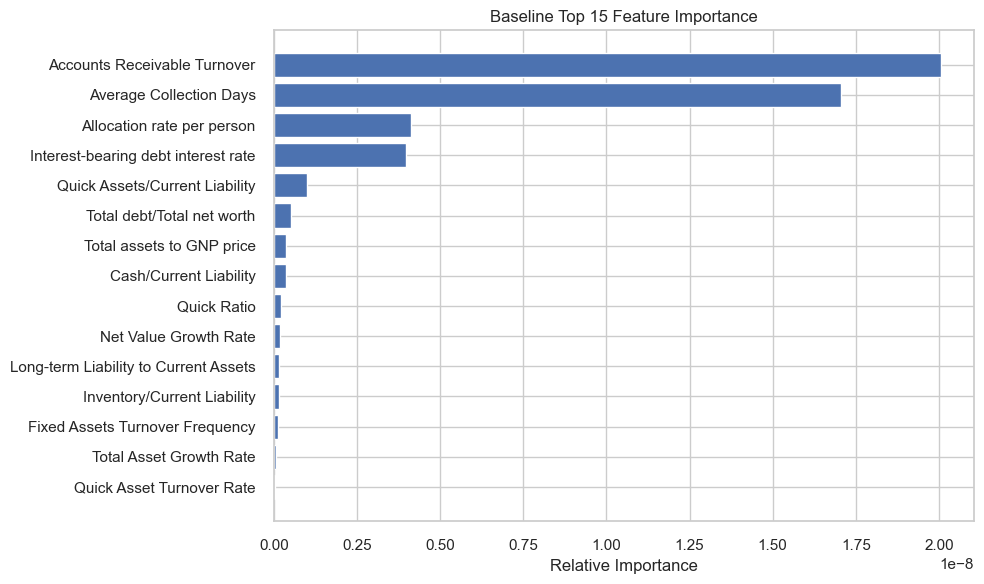

In [11]:
lr_baseline = LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', class_weight='balanced')
lr_baseline.fit(X_train, y_train)

# Evaluate
metrics = evaluate_model(lr_baseline, X_test, y_test, "Logistic Baseline")
results_log.append(metrics)

# Plot top features (Linear model uses coefficients)
plot_feature_importance(lr_baseline, X.columns, title_prefix="Baseline")

# ## 5. Feature Selection
# Reducing dimensions can help reduce noise and overfitting.

In [ ]:
pipeline_kbest = Pipeline([
    ('selector', SelectKBest(f_classif)),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', class_weight='balanced'))
])

# Tuning 'k' (number of features)
params = {'selector__k': range(1, 40, 2)} # Step of 2 for speed
grid_kbest = GridSearchCV(pipeline_kbest, params, scoring='f1', cv=5, n_jobs=-1)
grid_kbest.fit(X_train, y_train)

print(f"Optimal number of features (KBest): {grid_kbest.best_params_['selector__k']}")
print(f"Best CV F1-score: {grid_kbest.best_score_:.4f}")

# Evaluate best model
best_kbest_model = grid_kbest.best_estimator_
metrics = evaluate_model(best_kbest_model, X_test, y_test, "SelectKBest + LR")
results_log.append(metrics)

### 5.2. Wrapper Method: Sequential Feature Selector (SFS)
Iteratively adds features that improve model performance. Slower but considers feature interactions.

In [ ]:
# Note: Using n_features_to_select='auto' or a fixed small number to save time
sfs_selector = SequentialFeatureSelector(
    estimator=LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', class_weight='balanced'),
    n_features_to_select=10, # Selecting top 10 features for demonstration
    direction='forward',
    scoring='f1',
    cv=3,
    n_jobs=-1
)
sfs_selector.fit(X_train, y_train)

print(f"SFS Selected {len(sfs_selector.get_support(indices=True))} features.")

# Transform data
X_train_sfs = sfs_selector.transform(X_train)
X_test_sfs = sfs_selector.transform(X_test)

# Train on selected features
lr_sfs = LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', class_weight='balanced')
lr_sfs.fit(X_train_sfs, y_train)

# Evaluate
metrics = evaluate_model(lr_sfs, X_test_sfs, y_test, "SFS (10 feats) + LR")
results_log.append(metrics)

5.3. Embedded Method: L1 Regularization (Lasso)
L1 regularization forces coefficients of unimportant features to zero.

In [ ]:
# Scaling is crucial for L1 regularization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Grid search for 'C' (Inverse of regularization strength)
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)
params_l1 = {'C': [0.01, 0.05, 0.1, 0.5, 1, 5]}

grid_l1 = GridSearchCV(lr_l1, params_l1, scoring='f1', cv=5, n_jobs=-1)
grid_l1.fit(X_train_scaled, y_train)

print(f"Optimal C: {grid_l1.best_params_['C']}")

# Evaluate
best_l1_model = grid_l1.best_estimator_
metrics = evaluate_model(best_l1_model, X_test_scaled, y_test, "Lasso (L1) LR")
results_log.append(metrics)

# Analyze selected features
mask = best_l1_model.coef_[0] != 0
selected_features_l1 = X.columns[mask]
print(f"L1 selected {sum(mask)} features out of {X.shape[1]}")

# Create datasets with ONLY L1-selected features for Boosting models
X_train_selected = X_train.loc[:, mask]
X_test_selected = X_test.loc[:, mask]

## 6. Gradient Boosting Models
We train Boosting models on the **features selected by L1 regularization** to improve efficiency and reduce noise.

In [ ]:
# 1. CatBoost
print("\nTraining CatBoost...")
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    auto_class_weights='Balanced', # Handle imbalance
    verbose=0, # Silent mode
    random_state=RANDOM_STATE,
    early_stopping_rounds=50
)
cb_model.fit(X_train_selected, y_train, eval_set=(X_test_selected, y_test))

metrics = evaluate_model(cb_model, X_test_selected, y_test, "CatBoost (Selected)")
results_log.append(metrics)
plot_feature_importance(cb_model, selected_features_l1, title_prefix="CatBoost")

# 2. LightGBM
print("\nTraining LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    verbose=-1
)
lgbm_model.fit(X_train_selected, y_train)

metrics = evaluate_model(lgbm_model, X_test_selected, y_test, "LightGBM (Selected)")
results_log.append(metrics)

# 3. XGBoost
print("\nTraining XGBoost...")
# Calculate scale_pos_weight for XGBoost
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    scale_pos_weight=ratio,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_model.fit(X_train_selected, y_train)

metrics = evaluate_model(xgb_model, X_test_selected, y_test, "XGBoost (Selected)")
results_log.append(metrics)

## 7. Ensemble
Combining predictions from different models to improve stability.

In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('catboost', cb_model),
        ('lightgbm', lgbm_model),
        ('xgboost', xgb_model)
    ],
    voting='soft'
)

voting_clf.fit(X_train_selected, y_train)
metrics = evaluate_model(voting_clf, X_test_selected, y_test, "Voting Ensemble")
results_log.append(metrics)

## 8. Final Results and Business Metrics
Comparison of all experiments.

In [ ]:
# ## 8. Final Results and Business Metrics
# Comparison of all experiments.

# %% [code]
# Create summary DataFrame
results_df = pd.DataFrame(results_log).set_index('Model').sort_values('ROC-AUC', ascending=False)

print("\n=== FINAL LEADERBOARD ===")
# Display with color gradient (works in Notebooks)
try:
    display(results_df.style.background_gradient(cmap='viridis', subset=['ROC-AUC', 'PR-AUC', 'F1-Score']))
except:
    print(results_df)

# Business Insight Calculation
# Assuming:
# - False Negative (Missed bankruptcy): Very costly (e.g., Loss = 100 units)
# - False Positive (False alarm): Moderate cost (e.g., Audit cost = 5 units)

best_model_name = results_df.index[0]
print(f"\nBest Model by ROC-AUC: {best_model_name}")

# Example logic for business decision
# (Using confusion matrix data from the best model - re-calculating for demonstration)
if "Voting" in best_model_name:
    final_model = voting_clf
    X_final = X_test_selected
elif "CatBoost" in best_model_name:
    final_model = cb_model
    X_final = X_test_selected
else:
    final_model = lr_baseline # Fallback
    X_final = X_test

y_pred_final = final_model.predict(X_final)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

cost_fn = 100
cost_fp = 5
total_cost = (fn * cost_fn) + (fp * cost_fp)

print(f"\nBusiness Impact Analysis ({best_model_name}):")
print(f"Missed Bankruptcies (FN): {fn} (Cost: {fn * cost_fn})")
print(f"False Alarms (FP): {fp} (Cost: {fp * cost_fp})")
print(f"Total Estimated Risk Cost: {total_cost}")

In [ ]:
...